In [2]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [3]:
import sys
print(sys.executable)


/opt/conda/bin/python


In [4]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [5]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [8]:
ds_forecast

<xarray.Dataset> Size: 5GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 42, latitude: 33)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 336B 88.5 90.0 ... 148.5 150.0
  * latitude                  (latitude) float64 264B -16.5 -15.0 ... 30.0 31.5
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB ...

In [9]:
ds_truth

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


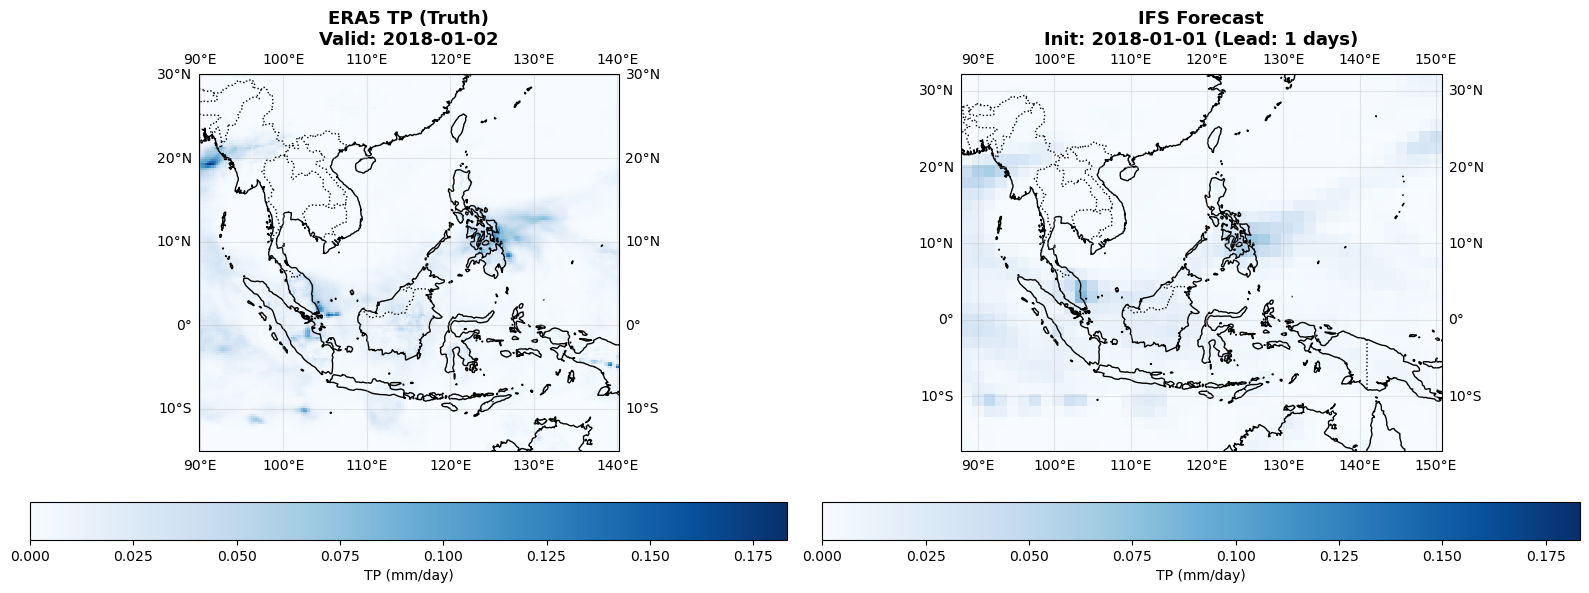

Truth range: 0.00 - 0.18 mm/day
Forecast range: 0.00 - 0.08 mm/day
Common color scale: 0.00 - 0.18 mm/day


In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

base_start_date = "2018-01-01"
lead_days = 1

target_dt = pd.to_datetime(base_start_date) + pd.Timedelta(days=lead_days)
target_date_str = target_dt.strftime("%Y-%m-%d")
lead_str = f"{lead_days} days"

data1 = ds_truth["total_precipitation_24hr"].sel(time="2018-01-02").copy()
data2 = (
    ds_forecast["total_precipitation_24hr"]
    .sel(time="2018-01-01", prediction_timedelta="1 days")
    .copy()
)

# Extract data for 2018-01-01
truth_2018 = data1.isel(time=0)  # Select first timestep
forecast_2018 = data2.isel(time=0)  # Select first timestep

# Determine common color scale range
vmin = min(truth_2018.values.min(), forecast_2018.values.min())
vmax = max(truth_2018.values.max(), forecast_2018.values.max())

# Create map projection
proj = ccrs.PlateCarree()

# Create side-by-side map plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={"projection": proj})

# Plot truth
im1 = axes[0].pcolormesh(
    truth_2018.longitude,
    truth_2018.latitude,
    truth_2018.values,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    shading="nearest",
    vmin=vmin,
    vmax=vmax,
)
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linestyle=":")
axes[0].gridlines(draw_labels=True, alpha=0.3)
axes[0].set_title(
    f"ERA5 TP (Truth)\nValid: {target_date_str}", fontsize=13, fontweight="bold"
)
plt.colorbar(im1, ax=axes[0], label="TP (mm/day)", orientation="horizontal", pad=0.1)

# Plot forecast
im2 = axes[1].pcolormesh(
    forecast_2018.longitude.values,
    forecast_2018.latitude.values,
    forecast_2018.values.T,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linestyle=":")
axes[1].gridlines(draw_labels=True, alpha=0.3)
axes[1].set_title(
    f"IFS Forecast\nInit: {base_start_date} (Lead: {lead_str})",
    fontsize=13,
    fontweight="bold",
)
plt.colorbar(im2, ax=axes[1], label="TP (mm/day)", orientation="horizontal", pad=0.1)

plt.tight_layout()
plt.show()

print(
    f"Truth range: {truth_2018.values.min():.2f} - {truth_2018.values.max():.2f} mm/day"
)
print(
    f"Forecast range: {forecast_2018.values.min():.2f} - {forecast_2018.values.max():.2f} mm/day"
)
print(f"Common color scale: {vmin:.2f} - {vmax:.2f} mm/day")

In [8]:
# Select a specific time and lead time from forecast
forecast_sample = ds_forecast['total_precipitation_24hr'].sel(
    time='2018-01-01', 
    prediction_timedelta='1 days'
).isel(time=0)

# Select corresponding truth data
truth_sample = ds_truth['total_precipitation_24hr'].sel(time='2018-01-02').isel(time=0)
print(f"Forecast shape: {forecast_sample.shape}")
print(f"Truth shape: {truth_sample.shape}")
print(f"Forecast resolution: lat={len(forecast_sample.latitude)}, lon={len(forecast_sample.longitude)}")
print(f"Truth resolution: lat={len(truth_sample.latitude)}, lon={len(truth_sample.longitude)}")

# Create regridder for downscaling (bilinear is common for precipitation spatial interpolation)
regridder = xe.Regridder(
    forecast_sample,
    truth_sample,
    method='bilinear',  # Use 'conservative' for mass-conserving downscaling
    periodic=False
)

# Apply regridding to downscale forecast to truth resolution
forecast_downscaled = regridder(forecast_sample)

print(f"\nDownscaled forecast shape: {forecast_downscaled.shape}")
print(f"Downscaled matches truth grid: {forecast_downscaled.shape == truth_sample.shape}")

Forecast shape: (42, 33)
Truth shape: (181, 201)
Forecast resolution: lat=33, lon=42
Truth resolution: lat=181, lon=201


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')



Downscaled forecast shape: (181, 201)
Downscaled matches truth grid: True


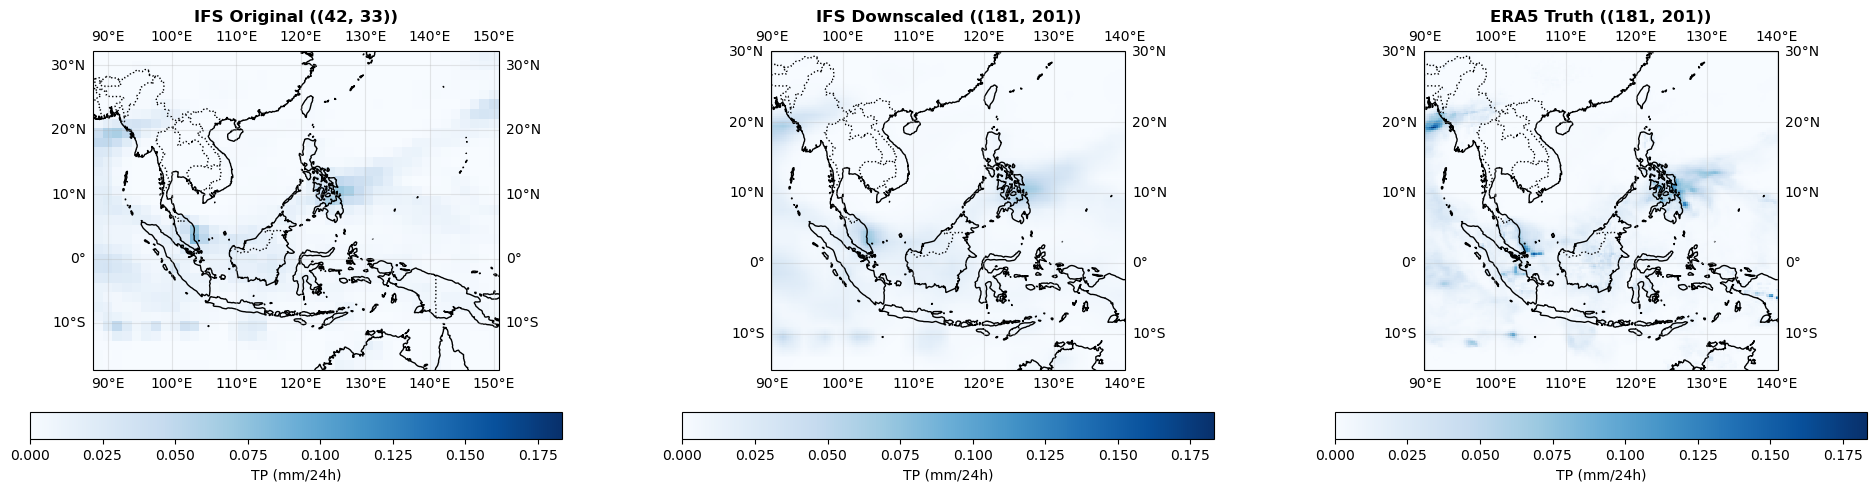

Original forecast: 0.00 - 0.08 mm/24h
Downscaled forecast: 0.00 - 0.08 mm/24h
Truth: 0.00 - 0.18 mm/24h


In [9]:
# Determine common color scale
vmin = min(truth_sample.values.min(), forecast_downscaled.values.min())
vmax = max(truth_sample.values.max(), forecast_downscaled.values.max())

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(20, 5), subplot_kw={'projection': proj})

# Original forecast (low res)
im0 = axes[0].pcolormesh(forecast_sample.longitude, forecast_sample.latitude, 
                          forecast_sample.values.T,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linestyle=':')
axes[0].gridlines(draw_labels=True, alpha=0.3)
axes[0].set_title(f'IFS Original ({forecast_sample.shape})', fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[0], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# Downscaled forecast (high res)
im1 = axes[1].pcolormesh(forecast_downscaled.longitude, forecast_downscaled.latitude, 
                          forecast_downscaled.values,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linestyle=':')
axes[1].gridlines(draw_labels=True, alpha=0.3)
axes[1].set_title(f'IFS Downscaled ({forecast_downscaled.shape})', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[1], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# Truth (high res)
im2 = axes[2].pcolormesh(truth_sample.longitude, truth_sample.latitude, 
                          truth_sample.values,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[2].coastlines()
axes[2].add_feature(cfeature.BORDERS, linestyle=':')
axes[2].gridlines(draw_labels=True, alpha=0.3)
axes[2].set_title(f'ERA5 Truth ({truth_sample.shape})', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[2], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

plt.tight_layout()
plt.show()

print(f"Original forecast: {forecast_sample.values.min():.2f} - {forecast_sample.values.max():.2f} mm/24h")
print(f"Downscaled forecast: {forecast_downscaled.values.min():.2f} - {forecast_downscaled.values.max():.2f} mm/24h")
print(f"Truth: {truth_sample.values.min():.2f} - {truth_sample.values.max():.2f} mm/24h")

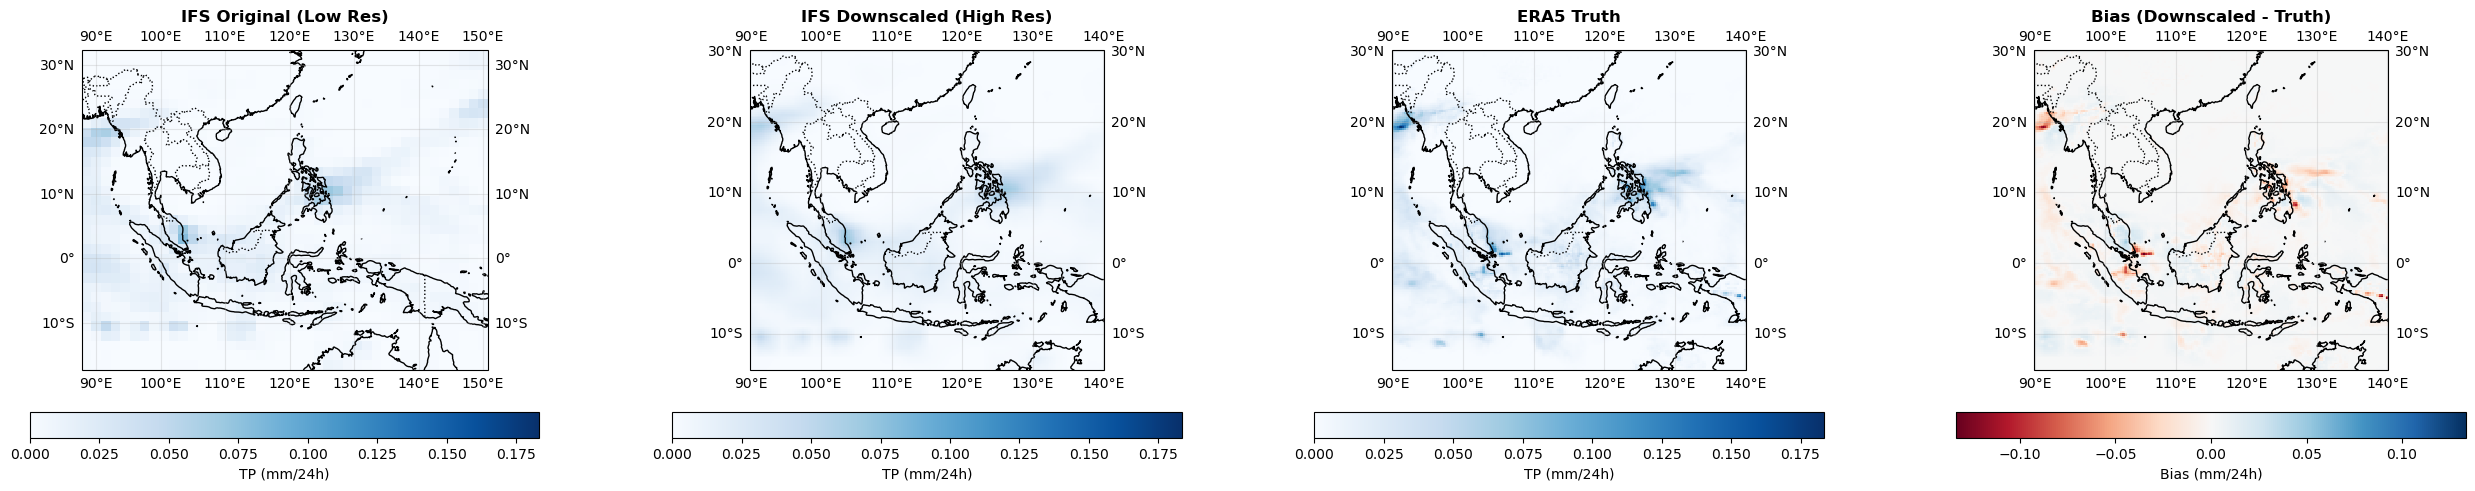

Original forecast: 0.00 - 0.08 mm
Downscaled forecast: 0.00 - 0.08 mm
Truth: 0.00 - 0.18 mm
Bias Range: -0.13 to 0.04 mm


In [10]:
# 1. Calculate the Bias
# Assuming forecast_downscaled and truth_sample are on the same grid/coordinates
bias = forecast_downscaled - truth_sample

# 2. Determine scales
# Global min/max for the raw values (TP)
vmin = min(truth_sample.values.min(), forecast_downscaled.values.min())
vmax = max(truth_sample.values.max(), forecast_downscaled.values.max())

# Symmetric limit for the Bias (so 0 is white)
bias_limit = max(abs(bias.values.min()), abs(bias.values.max()))

proj = ccrs.PlateCarree()
# Changed to 4 columns to include the Bias plot
fig, axes = plt.subplots(1, 4, figsize=(26, 5), subplot_kw={'projection': proj})

# --- Panel 1: Original Forecast ---
im0 = axes[0].pcolormesh(forecast_sample.longitude, forecast_sample.latitude, 
                          forecast_sample.values.T, # Kept the transpose from your snippet
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linestyle=':')
axes[0].set_title(f'IFS Original (Low Res)', fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[0], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# --- Panel 2: Downscaled Forecast ---
im1 = axes[1].pcolormesh(forecast_downscaled.longitude, forecast_downscaled.latitude, 
                          forecast_downscaled.values,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linestyle=':')
axes[1].set_title(f'IFS Downscaled (High Res)', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[1], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# --- Panel 3: ERA5 Truth ---
im2 = axes[2].pcolormesh(truth_sample.longitude, truth_sample.latitude, 
                          truth_sample.values,
                          transform=ccrs.PlateCarree(), cmap='Blues', 
                          vmin=vmin, vmax=vmax, shading='auto')
axes[2].coastlines()
axes[2].add_feature(cfeature.BORDERS, linestyle=':')
axes[2].set_title(f'ERA5 Truth', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[2], label='TP (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# --- Panel 4: Bias (Downscaled - Truth) ---
im3 = axes[3].pcolormesh(bias.longitude, bias.latitude, 
                          bias.values,
                          transform=ccrs.PlateCarree(), 
                          cmap='RdBu',  # Diverging colormap (Red=Dry, Blue=Wet)
                          vmin=-bias_limit, vmax=bias_limit, # Symmetric scale
                          shading='auto')
axes[3].coastlines()
axes[3].add_feature(cfeature.BORDERS, linestyle=':')
axes[3].set_title(f'Bias (Downscaled - Truth)', fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=axes[3], label='Bias (mm/24h)', orientation='horizontal', pad=0.1, shrink=0.8)

# Common Gridlines
for ax in axes:
    ax.gridlines(draw_labels=True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats output
print(f"Original forecast: {forecast_sample.values.min():.2f} - {forecast_sample.values.max():.2f} mm")
print(f"Downscaled forecast: {forecast_downscaled.values.min():.2f} - {forecast_downscaled.values.max():.2f} mm")
print(f"Truth: {truth_sample.values.min():.2f} - {truth_sample.values.max():.2f} mm")
print(f"Bias Range: {bias.values.min():.2f} to {bias.values.max():.2f} mm")

Comparing methods: ['bilinear', 'conservative', 'conservative_normed', 'nearest_s2d', 'patch', 'nearest_d2s']

Processing method: bilinear...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Processing method: conservative...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Processing method: conservative_normed...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Processing method: nearest_s2d...
Processing method: patch...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Processing method: nearest_d2s...


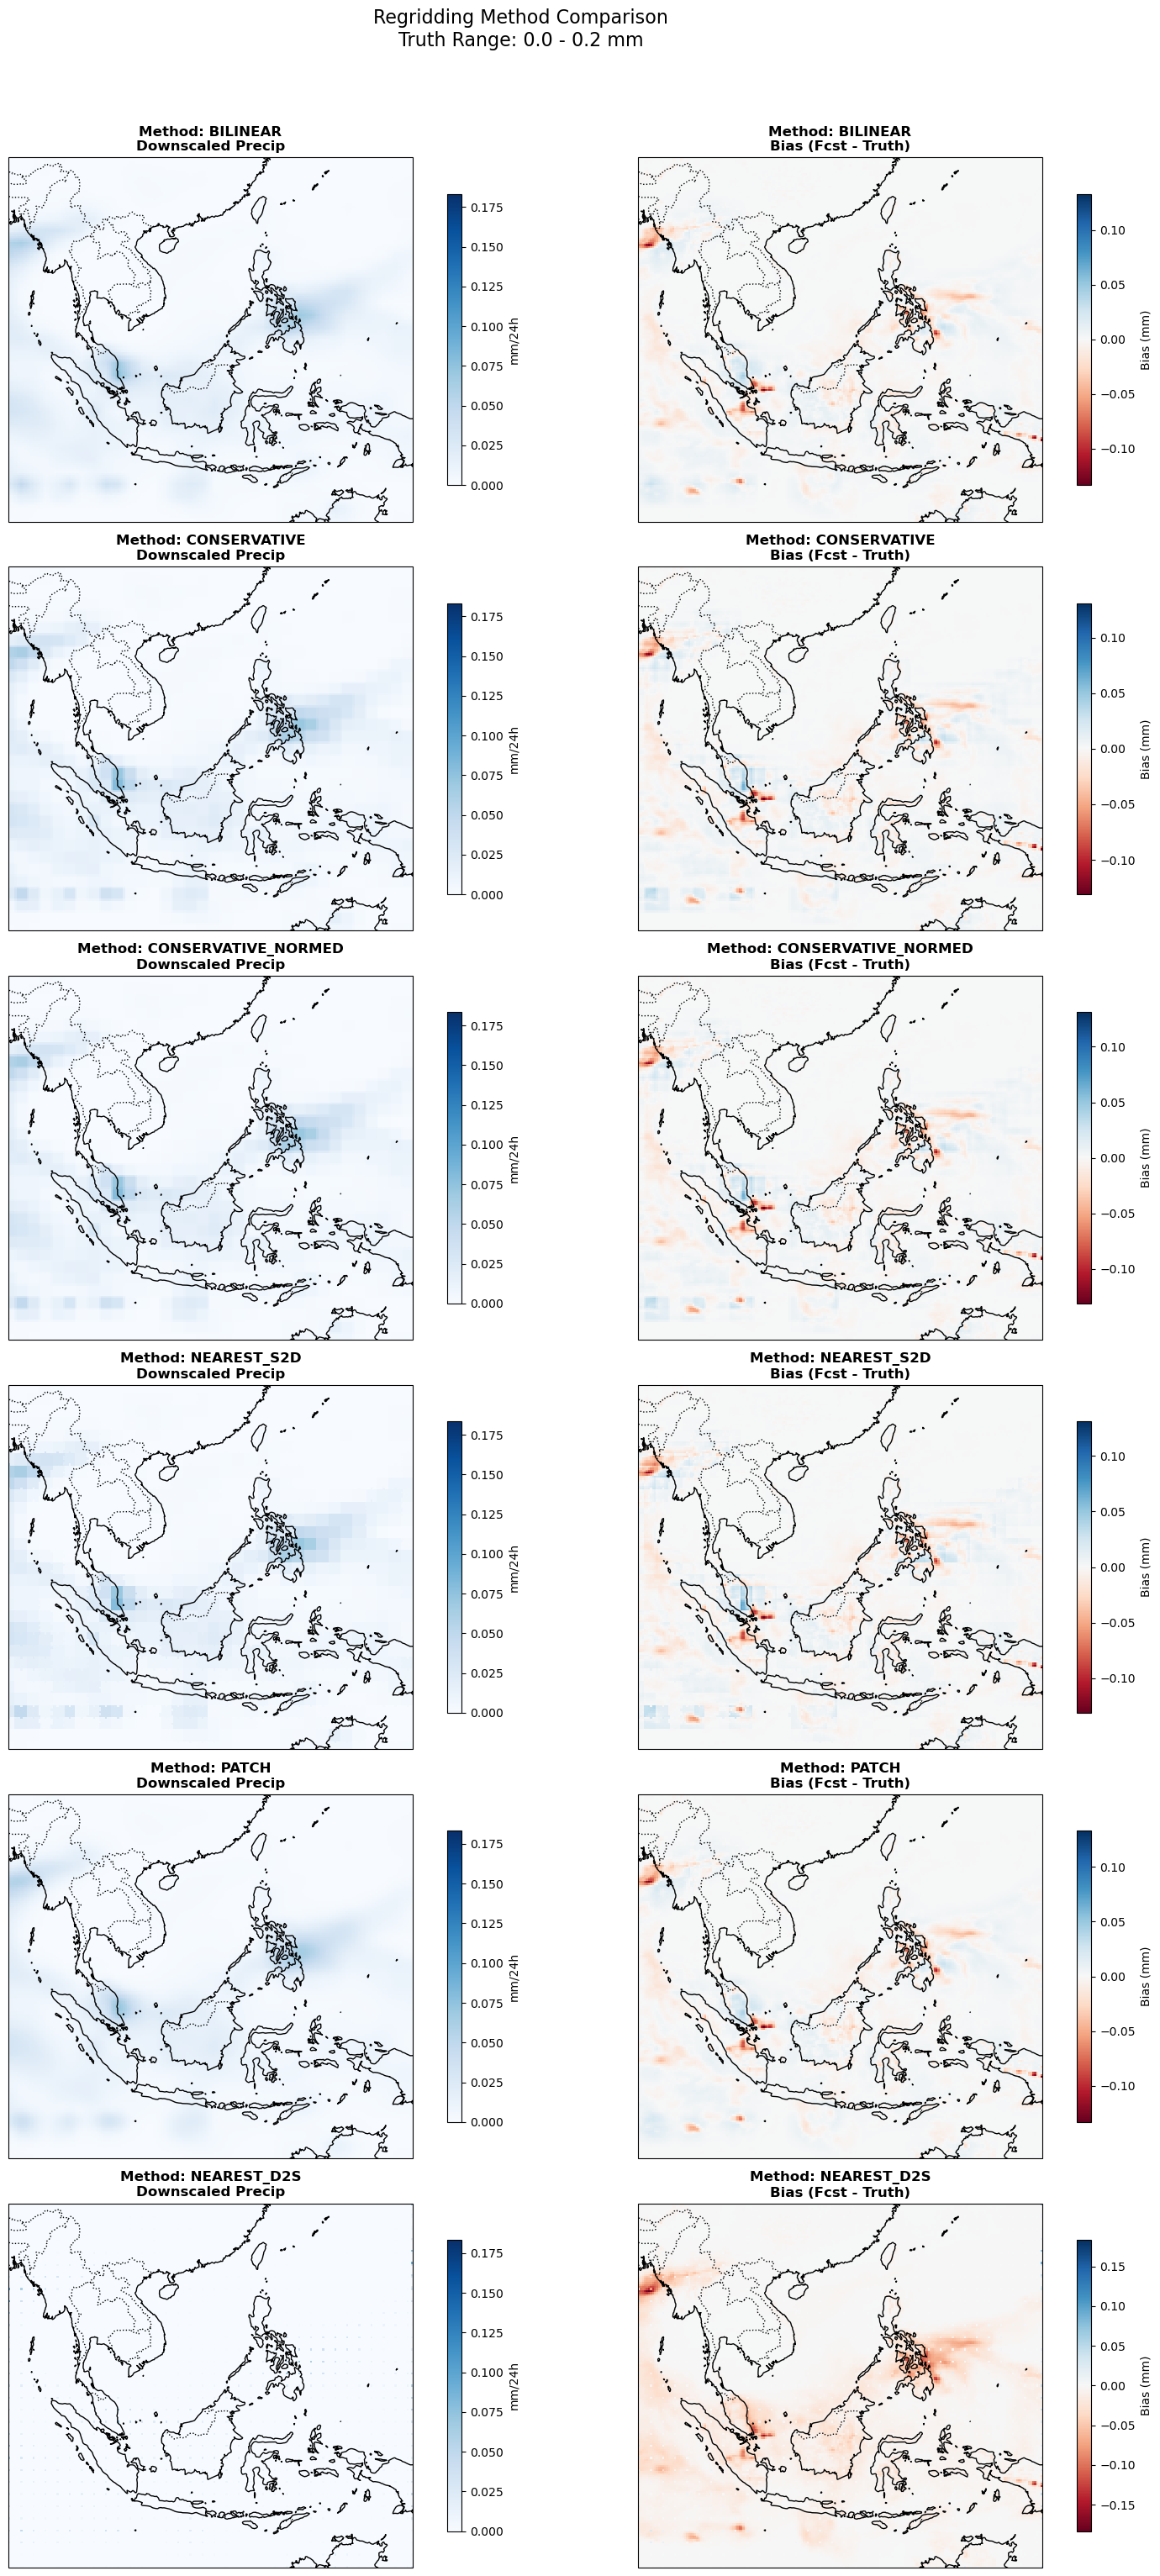

In [12]:
# 1. Define the methods you want to compare
# Note: 'conservative' requires grid corners (lat_b, lon_b) to be defined in your dataset.
regrid_methods = ['bilinear', 'conservative', 'conservative_normed', 'nearest_s2d', 'patch', 'nearest_d2s'] 

# 2. Setup Plotting Scales (Global min/max for consistent colors)
vmin_precip = min(truth_sample.values.min(), forecast_sample.values.min())
vmax_precip = max(truth_sample.values.max(), forecast_sample.values.max())

# Initialize figure
# Rows = Number of methods, Cols = 2 (Downscaled Field + Bias Field)
fig, axes = plt.subplots(len(regrid_methods), 2, figsize=(16, 5 * len(regrid_methods)), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Handle case where there is only 1 method (axes becomes 1D array)
if len(regrid_methods) == 1:
    axes = np.expand_dims(axes, axis=0)

print(f"Comparing methods: {regrid_methods}\n")

for i, method in enumerate(regrid_methods):
    print(f"Processing method: {method}...")
    
    # --- A. Perform Regridding ---
    regridder = xe.Regridder(
        forecast_sample,
        truth_sample,
        method=method,
        periodic=False,
        reuse_weights=False # Set to True if you run this multiple times to save time
    )
    
    forecast_downscaled = regridder(forecast_sample)
    
    # --- B. Calculate Bias ---
    bias = forecast_downscaled - truth_sample
    
    # Dynamic scale for bias (centered on 0)
    bias_limit = max(abs(bias.values.min()), abs(bias.values.max()))

    # --- C. Plot Column 1: Downscaled Forecast ---
    ax_fc = axes[i, 0]
    im_fc = ax_fc.pcolormesh(forecast_downscaled.longitude, forecast_downscaled.latitude, 
                             forecast_downscaled.values,
                             transform=ccrs.PlateCarree(), cmap='Blues', 
                             vmin=vmin_precip, vmax=vmax_precip, shading='auto')
    
    ax_fc.coastlines()
    ax_fc.add_feature(cfeature.BORDERS, linestyle=':')
    ax_fc.set_title(f'Method: {method.upper()}\nDownscaled Precip', fontsize=12, fontweight='bold')
    plt.colorbar(im_fc, ax=ax_fc, label='mm/24h', shrink=0.8)

    # --- D. Plot Column 2: Bias (Forecast - Truth) ---
    ax_bias = axes[i, 1]
    im_bias = ax_bias.pcolormesh(bias.longitude, bias.latitude, 
                                 bias.values,
                                 transform=ccrs.PlateCarree(), cmap='RdBu', 
                                 vmin=-bias_limit, vmax=bias_limit, shading='auto')
    
    ax_bias.coastlines()
    ax_bias.add_feature(cfeature.BORDERS, linestyle=':')
    ax_bias.set_title(f'Method: {method.upper()}\nBias (Fcst - Truth)', fontsize=12, fontweight='bold')
    plt.colorbar(im_bias, ax=ax_bias, label='Bias (mm)', shrink=0.8)

plt.suptitle(f"Regridding Method Comparison\nTruth Range: {truth_sample.values.min():.1f} - {truth_sample.values.max():.1f} mm", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# import tensorflow and required stuff from Keras API
import tensorflow as tf

# all the layers used for U-net
from tensorflow.keras.layers import (Activation, BatchNormalization, Concatenate, Conv2D,
                                     Conv2DTranspose, Input, MaxPool2D
)
from tensorflow.keras.models import Model

def conv_block(inputs, num_filters: int, kernel: tuple = (3,3), padding: str = "same",
               activation: str = "relu", kernel_init: str = "he_normal", l_batch_normalization: bool = True):
    """
    A convolutional layer with optional batch normalization
    :param inputs: the input data with dimensions nx, ny and nc
    :param num_filters: number of filters (output channel dimension)
    :param kernel: tuple indictating kernel size
    :param padding: technique for padding (e.g. "same" or "valid")
    :param activation: activation fuction for neurons (e.g. "relu")
    :param kernel_init: initialization technique (e.g. "he_normal" or "glorot_uniform")
    """
    
    x = Conv2D(num_filters, kernel, padding=padding, kernel_initializer=kernel_init)(inputs)
    if l_batch_normalization:
        x = BatchNormalization()(x)
    x = Activation(activation)(x)
    
    return x

def conv_block_n(inputs, num_filters, n=2, kernel=(3,3), padding="same", activation="relu", 
                     kernel_init="he_normal", l_batch_normalization=True):
    """
    Sequential application of two convolutional layers (using conv_block).
    """
    
    x = conv_block(inputs, num_filters, kernel, padding, activation,
                   kernel_init, l_batch_normalization)
    for i in np.arange(n-1):
        x = conv_block(x, num_filters, kernel, padding, activation,
                       kernel_init, l_batch_normalization)
    
    return x

def encoder_block(inputs, num_filters, kernel_maxpool: tuple=(2,2), l_large: bool=True):
    """
    One complete encoder-block used in U-net
    """
    if l_large:
        x = conv_block_n(inputs, num_filters, n=2)
    else:
        x = conv_block(inputs, num_filters)
        
    p = MaxPool2D(kernel_maxpool)(x)
    
    return x, p

def decoder_block(inputs, skip_features, num_filters, kernel: tuple=(3,3), strides_up: int=2, padding: str= "same", 
                  activation="relu", kernel_init="he_normal", l_batch_normalization: bool=True):
    """
    One complete decoder block used in U-net (reverting the encoder)
    """
    
    x = Conv2DTranspose(num_filters, (strides_up, strides_up), strides=strides_up, padding="same")(inputs)
    x = Concatenate()([x, skip_features])
    x = conv_block_n(x, num_filters, 2, kernel, padding, activation, kernel_init, l_batch_normalization)
    
    return x

In [7]:
def build_unet(input_shape, channels_start=56, z_branch=False):
    
    inputs = Input(input_shape)
    
    """ encoder """
    s1, e1 = encoder_block(inputs, channels_start, l_large=True)
    s2, e2 = encoder_block(e1, channels_start*2, l_large=False)
    s3, e3 = encoder_block(e2, channels_start*4, l_large=False)
    
    """ bridge encoder <-> decoder """
    b1 = conv_block(e3, channels_start*8)
    
    """ decoder """
    d1 = decoder_block(b1, s3, channels_start*4)
    d2 = decoder_block(d1, s2, channels_start*2)
    d3 = decoder_block(d2, s1, channels_start)
    
    output_temp = Conv2D(1, (1,1), kernel_initializer="he_normal", name="output_temp")(d3)
    if z_branch:
        output_z = Conv2D(1, (1, 1), kernel_initializer="he_normal", name="output_z")(d3)

        model = Model(inputs, [output_temp, output_z], name="t2m_downscaling_unet_with_z")
    else:    
        model = Model(inputs, output_temp, name="t2m_downscaling_unet")
    
    return model

In [7]:
import tensorflow.keras.utils as ku
shape_in = (96, 128, 3)
unet_model = build_unet(shape_in, z_branch=True)

ku.plot_model(unet_model, show_shapes=True)

I0000 00:00:1770797697.231054     504 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46524 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:06:10.0, compute capability: 8.9


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [8]:
import xarray as xr
import datetime as dt
import numpy as np
import xesmf as xe

def preprocess_data_for_unet(ds_forecast, ds_truth, daytime=12, prediction_lead_time=0, opt_norm={}, regridder=None):
    """
    Preprocess the data for feeding into the U-net, i.e. conversion to data arrays incl. z-score normalization
    :param ds_forecast: the forecast dataset with prediction_timedelta dimension
    :param ds_truth: the ground truth dataset
    :param daytime: daytime in UTC for temporal slicing (hour of day, 0-23)
    :param prediction_lead_time: which prediction_timedelta to use (0-60 days)
    :param opt_norm: dictionary holding data for z-score normalization
    :param regridder: pre-computed xesmf regridder (optional, will be created if None)
    :return: normalized data ready to be fed to U-net model (and regridder if newly created)
    """
    norm_dims_t = ["time"]                          # normalization of 2m temperature for each grid point
    norm_dims_other = ["time", "latitude", "longitude"]  # 'global' normalization
    
    # Slice forecast data by time of day and prediction lead time
    dsf = ds_forecast.sel(time=ds_forecast.time.dt.hour == daytime)
    dsf = dsf.isel(prediction_timedelta=prediction_lead_time)
    
    # Slice truth data by time of day
    dst = ds_truth.sel(time=ds_truth.time.dt.hour == daytime)
    
    # Align the time coordinates (ds_truth has more frequent observations)
    # Match truth times to forecast times
    dst = dst.sel(time=dsf.time, method='nearest')
    
    # Create or use regridder to interpolate truth data to forecast grid
    regridder_created = False
    if regridder is None:
        # Create target grid from forecast
        ds_out = xr.Dataset({
            'latitude': (['latitude'], dsf.latitude.values),
            'longitude': (['longitude'], dsf.longitude.values),
        })
        
        # Create source grid from truth
        ds_in = xr.Dataset({
            'latitude': (['latitude'], dst.latitude.values),
            'longitude': (['longitude'], dst.longitude.values),
        })
        
        # Create regridder (bilinear interpolation)
        regridder = xe.Regridder(ds_in, ds_out, 'bilinear', periodic=False)
        regridder_created = True
    
    # Regrid truth data to match forecast spatial resolution
    t2m_tar = regridder(dst["2m_temperature"])
    u_tar = regridder(dst["10m_u_component_of_wind"])
    v_tar = regridder(dst["10m_v_component_of_wind"])
    precip_tar = regridder(dst["total_precipitation_24hr"])
    
    # Prepare input data from forecast (all 4 variables)
    t2m_in = dsf["2m_temperature"]
    u_in = dsf["10m_u_component_of_wind"]
    v_in = dsf["10m_v_component_of_wind"]
    precip_in = dsf["total_precipitation_24hr"]
    
    # Normalize data
    if not opt_norm:
        # Calculate normalization statistics
        t2m_in_norm, t2m_in_mu, t2m_in_std = z_norm_data(t2m_in, dims=norm_dims_t, return_stat=True)
        u_in_norm, u_in_mu, u_in_std = z_norm_data(u_in, dims=norm_dims_other, return_stat=True)
        v_in_norm, v_in_mu, v_in_std = z_norm_data(v_in, dims=norm_dims_other, return_stat=True)
        precip_in_norm, precip_in_mu, precip_in_std = z_norm_data(precip_in, dims=norm_dims_other, return_stat=True)
        
        t2m_tar_norm, t2m_tar_mu, t2m_tar_std = z_norm_data(t2m_tar, dims=norm_dims_t, return_stat=True)
        u_tar_norm, u_tar_mu, u_tar_std = z_norm_data(u_tar, dims=norm_dims_other, return_stat=True)
        v_tar_norm, v_tar_mu, v_tar_std = z_norm_data(v_tar, dims=norm_dims_other, return_stat=True)
        precip_tar_norm, precip_tar_mu, precip_tar_std = z_norm_data(precip_tar, dims=norm_dims_other, return_stat=True)
        
    else:
        # Use provided normalization statistics
        t2m_in_norm = z_norm_data(t2m_in, mu=opt_norm["mu_t2m_in"], std=opt_norm["std_t2m_in"])
        u_in_norm = z_norm_data(u_in, mu=opt_norm["mu_u_in"], std=opt_norm["std_u_in"])
        v_in_norm = z_norm_data(v_in, mu=opt_norm["mu_v_in"], std=opt_norm["std_v_in"])
        precip_in_norm = z_norm_data(precip_in, mu=opt_norm["mu_precip_in"], std=opt_norm["std_precip_in"])
        
        t2m_tar_norm = z_norm_data(t2m_tar, mu=opt_norm["mu_t2m_tar"], std=opt_norm["std_t2m_tar"])
        u_tar_norm = z_norm_data(u_tar, mu=opt_norm["mu_u_tar"], std=opt_norm["std_u_tar"])
        v_tar_norm = z_norm_data(v_tar, mu=opt_norm["mu_v_tar"], std=opt_norm["std_v_tar"])
        precip_tar_norm = z_norm_data(precip_tar, mu=opt_norm["mu_precip_tar"], std=opt_norm["std_precip_tar"])
    
    # Concatenate input and target variables
    in_data = xr.concat([t2m_in_norm, u_in_norm, v_in_norm, precip_in_norm], dim="variable")
    tar_data = xr.concat([t2m_tar_norm, u_tar_norm, v_tar_norm, precip_tar_norm], dim="variable")
    
    # Re-order dimensions: (time, latitude, longitude, variable)
    in_data = in_data.transpose("time", "latitude", "longitude", "variable")
    tar_data = tar_data.transpose("time", "latitude", "longitude", "variable")
    
    if not opt_norm:
        opt_norm = {
            "mu_t2m_in": t2m_in_mu, "std_t2m_in": t2m_in_std,
            "mu_u_in": u_in_mu, "std_u_in": u_in_std,
            "mu_v_in": v_in_mu, "std_v_in": v_in_std,
            "mu_precip_in": precip_in_mu, "std_precip_in": precip_in_std,
            "mu_t2m_tar": t2m_tar_mu, "std_t2m_tar": t2m_tar_std,
            "mu_u_tar": u_tar_mu, "std_u_tar": u_tar_std,
            "mu_v_tar": v_tar_mu, "std_v_tar": v_tar_std,
            "mu_precip_tar": precip_tar_mu, "std_precip_tar": precip_tar_std
        }
        if regridder_created:
            return in_data, tar_data, opt_norm, regridder
        else:
            return in_data, tar_data, opt_norm
    else:
        if regridder_created:
            return in_data, tar_data, regridder
        else:
            return in_data, tar_data

def z_norm_data(data, mu=None, std=None, dims=None, return_stat=False):
    """
    Perform z-score normalization on the data
    :param data: the data-array
    :param mu: the mean used for normalization
    :param std: the standard deviation used for normalization
    :param dims: list of dimensions over which statistical quantities are calculated
    :param return_stat: flag if normalization statistics are returned
    :return: the normalized data (and optionally mu, std)
    """
    if mu is None and std is None:
        if not dims:
            dims = list(data.dims)
        mu = data.mean(dim=dims)
        std = data.std(dim=dims)
    
    # Avoid division by zero
    std = xr.where(std == 0, 1, std)
    
    data_out = (data - mu) / std
    
    if return_stat:
        return data_out, mu, std
    else:
        return data_out

In [9]:
def split_data_by_date(ds_forecast, ds_truth, 
                       train_start='2018-01-01', train_end='2021-12-31',
                       val_start='2022-01-01', val_end='2022-06-30',
                       test_start='2022-07-01', test_end='2022-12-31'):
    """
    Split datasets by specific date ranges.
    
    :param ds_forecast: forecast dataset
    :param ds_truth: truth dataset
    :param train_start: training start date
    :param train_end: training end date
    :param val_start: validation start date
    :param val_end: validation end date
    :param test_start: test start date
    :param test_end: test end date
    :return: tuple of (train_forecast, train_truth, val_forecast, val_truth, test_forecast, test_truth)
    """
    # Split forecast data
    train_forecast = ds_forecast.sel(time=slice(train_start, train_end))
    val_forecast = ds_forecast.sel(time=slice(val_start, val_end))
    test_forecast = ds_forecast.sel(time=slice(test_start, test_end))
    
    # Split truth data
    train_truth = ds_truth.sel(time=slice(train_start, train_end))
    val_truth = ds_truth.sel(time=slice(val_start, val_end))
    test_truth = ds_truth.sel(time=slice(test_start, test_end))
    
    print(f"Train ({train_start} to {train_end}):")
    print(f"  Forecast: {len(train_forecast.time)} times")
    print(f"  Truth: {len(train_truth.time)} times")
    print(f"\nValidation ({val_start} to {val_end}):")
    print(f"  Forecast: {len(val_forecast.time)} times")
    print(f"  Truth: {len(val_truth.time)} times")
    print(f"\nTest ({test_start} to {test_end}):")
    print(f"  Forecast: {len(test_forecast.time)} times")
    print(f"  Truth: {len(test_truth.time)} times")
    
    return train_forecast, train_truth, val_forecast, val_truth, test_forecast, test_truth

def create_train_val_test_datasets(ds_forecast, ds_truth, 
                                   daytime=12,
                                   prediction_lead_time=0,
                                   **kwargs):
    """
    Main function to create train/val/test datasets with preprocessing.
    
    :param ds_forecast: forecast dataset
    :param ds_truth: truth dataset
    :param daytime: hour of day for temporal slicing (0-23)
    :param prediction_lead_time: which prediction lead time to use (0-60)
    :param kwargs: additional arguments for split functions
    :return: dictionary with all datasets and preprocessing info
    """
    import xesmf as xe
    
    # Split the data
    train_f, train_t, val_f, val_t, test_f, test_t = split_data_by_date(
        ds_forecast, ds_truth, **kwargs
    )
    
    # Preprocess training data (calculate normalization stats and create regridder)
    print("\n" + "="*60)
    print("Preprocessing training data...")
    print("="*60)
    train_in, train_tar, opt_norm, regridder = preprocess_data_for_unet(
        train_f, train_t, 
        daytime=daytime, 
        prediction_lead_time=prediction_lead_time
    )
    print(f"Train input shape: {train_in.shape}")
    print(f"Train target shape: {train_tar.shape}")
    
    # Preprocess validation data (use training normalization stats and regridder)
    print("\n" + "="*60)
    print("Preprocessing validation data...")
    print("="*60)
    val_in, val_tar = preprocess_data_for_unet(
        val_f, val_t, 
        daytime=daytime, 
        prediction_lead_time=prediction_lead_time,
        opt_norm=opt_norm, 
        regridder=regridder
    )
    print(f"Val input shape: {val_in.shape}")
    print(f"Val target shape: {val_tar.shape}")
    
    # Preprocess test data (use training normalization stats and regridder)
    print("\n" + "="*60)
    print("Preprocessing test data...")
    print("="*60)
    test_in, test_tar = preprocess_data_for_unet(
        test_f, test_t, 
        daytime=daytime, 
        prediction_lead_time=prediction_lead_time,
        opt_norm=opt_norm, 
        regridder=regridder
    )
    print(f"Test input shape: {test_in.shape}")
    print(f"Test target shape: {test_tar.shape}")
    
    print("\n" + "="*60)
    print("Data preparation complete!")
    print("="*60)
    
    return {
        'train_input': train_in,
        'train_target': train_tar,
        'val_input': val_in,
        'val_target': val_tar,
        'test_input': test_in,
        'test_target': test_tar,
        'opt_norm': opt_norm,
        'regridder': regridder
    }

In [10]:
data = create_train_val_test_datasets(
    ds_forecast, 
    ds_truth, 
    train_start='2018-01-01',
    train_end='2021-12-31',      # 4 years
    val_start='2022-01-01',
    val_end='2022-06-30',         # 6 months (0.5 year)
    test_start='2022-07-01',
    test_end='2022-12-31',        # 6 months (0.5 year)
    daytime=12,                   # Use 12:00 UTC data
    prediction_lead_time=1        # Same-day forecast
)

Train (2018-01-01 to 2021-12-31):
  Forecast: 2922 times
  Truth: 5844 times

Validation (2022-01-01 to 2022-06-30):
  Forecast: 362 times
  Truth: 724 times

Test (2022-07-01 to 2022-12-31):
  Forecast: 368 times
  Truth: 736 times

Preprocessing training data...


/opt/conda/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Train input shape: (1461, 33, 42, 4)
Train target shape: (1461, 33, 42, 4)

Preprocessing validation data...
Val input shape: (181, 33, 42, 4)
Val target shape: (181, 33, 42, 4)

Preprocessing test data...
Test input shape: (184, 33, 42, 4)
Test target shape: (184, 33, 42, 4)

Data preparation complete!


In [11]:
data.keys()

dict_keys(['train_input', 'train_target', 'val_input', 'val_target', 'test_input', 'test_target', 'opt_norm', 'regridder'])

In [16]:
data['train_input']

<xarray.DataArray '2m_temperature' (time: 1461, latitude: 32, longitude: 40,
                                    variable: 4)> Size: 30MB
array([[[[-8.87138620e-02, -1.51314509e+00,  7.26174951e-01,
                      nan],
         [-3.27241272e-02, -1.35781050e+00,  8.44496071e-01,
                      nan],
         [ 6.10148795e-02, -1.27178991e+00,  8.59061539e-01,
                      nan],
         ...,
         [ 1.93573129e+00,  1.36576667e-01, -8.49747956e-01,
                      nan],
         [ 1.57020664e+00,  4.50659603e-01, -7.24575937e-01,
                      nan],
         [ 1.60460317e+00,  1.68667257e-01, -1.68322432e+00,
                      nan]],

        [[ 6.58423603e-02, -1.40404034e+00,  8.03942978e-01,
                      nan],
         [ 8.60086083e-02, -1.35899794e+00,  9.50966656e-01,
                      nan],
         [ 6.30790591e-02, -1.44711351e+00,  8.93343449e-01,
                      nan],
...
         [-1.62752807e+00,  3.29509473e+00, -2.10593224e+00,
                      nan],
         [-1.54556012e+00,  3.54226971e+00, -2.10080791e+00,
                      nan],
         [-1.46987796e+00,  3.77437139e+00, -1.89770508e+00,
                      nan]],

        [[-1.89164162e+00,  4.96576041e-01,  7.72904754e-02,
                      nan],
         [-1.88919842e+00,  3.65099877e-01,  3.26634087e-02,
                      nan],
         [-1.91610420e+00,  1.84524298e-01, -2.70021021e-01,
                      nan],
         ...,
         [-1.80175233e+00,  3.47070193e+00, -2.47236681e+00,
                      nan],
         [-1.72673357e+00,  3.78614664e+00, -2.36378407e+00,
                      nan],
         [-1.59838533e+00,  4.18623686e+00, -2.03262258e+00,
                      nan]]]], dtype=float32)
Coordinates:
  * time                  (time) datetime64[ns] 12kB 2018-01-01T12:00:00 ... ...
  * latitude              (latitude) float64 256B -16.5 -15.0 ... 28.5 30.0
  * longitude             (longitude) float64 320B 88.5 90.0 ... 145.5 147.0
    prediction_timedelta  timedelta64[ns] 8B 06:00:00
Dimensions without coordinates: variable
Attributes:
    long_name:      2 metre temperature
    short_name:     t2m
    standard_name:  unknown
    units:          K

In [13]:
# Add this before training
print("Input - NaN count:", np.isnan(data['train_input'].values).sum())
print("Input - Inf count:", np.isinf(data['train_input'].values).sum())
print("Target - NaN count:", np.isnan(data['train_target'].values).sum())
print("Target - Inf count:", np.isinf(data['train_target'].values).sum())

Input - NaN count: 1870080
Input - Inf count: 0
Target - NaN count: 0
Target - Inf count: 0


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# 1. FIX DATA DIMENSIONS
# U-Net with 3 pooling layers requires spatial dims to be multiples of 8 (2^3).
# Current: (33, 42). Closest valid shape that fits is (32, 40).
# We crop the data slightly to fit.
def crop_to_multiple(ds_dict, multiple=8):
    # Get current shapes
    lat = ds_dict['train_input'].sizes['latitude']
    lon = ds_dict['train_input'].sizes['longitude']
    
    # Calculate new shapes (round down to nearest multiple)
    new_lat = (lat // multiple) * multiple
    new_lon = (lon // multiple) * multiple
    
    print(f"Cropping data from ({lat}, {lon}) to ({new_lat}, {new_lon}) for U-Net compatibility.")
    
    # Slice all datasets
    for key in ds_dict:
        if 'input' in key or 'target' in key:
            ds_dict[key] = ds_dict[key].isel(latitude=slice(0, new_lat), longitude=slice(0, new_lon))
    return ds_dict

# Apply cropping
data = crop_to_multiple(data, multiple=8)

# 2. FIX INPUT SHAPE
# Read shape dynamically from the processed data
# Shape will now be (32, 40, 4)
shape_in = data['train_input'].shape[1:] 
print(f"Model Input Shape: {shape_in}")

# 3. CONFIGURE MODEL
z_branch = False 

# Define learning-rate scheduler
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch >= 5 and epoch < 30:
        return float(lr * tf.math.exp(-0.1))
    elif epoch >= 30:
        return lr

callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Build model
unet_model = build_unet(shape_in, z_branch=z_branch)

# 4. FIX COMPILE
# Only include losses for outputs that actually exist
losses = {"output_temp": "mae"}
loss_weights = {"output_temp": 1.0}

if z_branch:
    losses["output_z"] = "mae"
    loss_weights["output_z"] = 1.0

unet_model.compile(optimizer=Adam(learning_rate=5*10**(-4)),
                   loss=losses, 
                   loss_weights=loss_weights)

# 5. FIX TRAINING DATA SHAPE
# Model expects target shape (Batch, Lat, Lon, 1)
# Selecting a single variable with .isel(variable=3) creates (Batch, Lat, Lon)
# Use slice(3, 4) to keep the channel dimension.
# variable=3 corresponds to Precipitation (based on your preprocessing order)
target_var_idx = 3 

history = unet_model.fit(
    x=data['train_input'].values, 
    y=data['train_target'].isel(variable=slice(target_var_idx, target_var_idx+1)).values,
    batch_size=8, 
    epochs=30, 
    callbacks=[callback], 
    validation_data=(
        data['val_input'].values, 
        data['val_target'].isel(variable=slice(target_var_idx, target_var_idx+1)).values
    )
)

Cropping data from (33, 42) to (32, 40) for U-Net compatibility.
Model Input Shape: (32, 40, 4)


I0000 00:00:1770877456.500916     126 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46524 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:06:10.0, compute capability: 8.9


Epoch 1/30


I0000 00:00:1770877463.616478     261 service.cc:148] XLA service 0x7c6ab4008a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770877463.616513     261 service.cc:156]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-02-12 06:24:23.744761: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770877464.440682     261 cuda_dnn.cc:529] Loaded cuDNN version 90300


 40/183 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan   

I0000 00:00:1770877469.071585     261 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: nan - val_loss: nan - learning_rate: 5.0000e-04
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 5.0000e-04
Epoch 3/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 5.0000e-04
Epoch 4/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 5.0000e-04
Epoch 5/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 5.0000e-04
Epoch 6/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 4.5242e-04
Epoch 7/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 4.0937e-04
Epoch 8/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 3.7041e-04
Epoch 9/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: nan - val_loss: nan - learning_rate: 3.3516e-04
Epoch 10/30
183/183 ━━━━━━━━━━━━━━━━━